# Mano Model Visualization and Animation

This notebook demonstrates how to load, manipulate, visualize and animate the Mano hand model using Python libraries like `manopth`, `trimesh`, and `matplotlib`. It covers setting up the environment, adjusting body shape and pose parameters, and creating interactive 3D animations.

**Pose and Shape Variations**


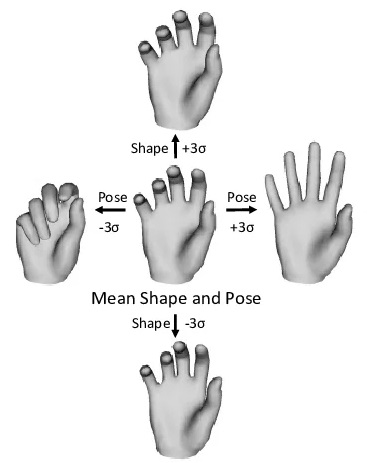

Image Source : https://www.researchgate.net/profile/Dan-Casas-2/publication/334434770/figure/fig1/AS:806300199968770@1569248356863/llustration-of-MANO-hand-model-left-that-is-augmented-with-our-collision-proxies-top.png

### **Initial Setup:**
This cell installs necessary Python libraries: `manopth` for Mano model generation functionality, `chumpy` to properly extract model file (.pkl) data without any errors  and `trimesh` for 3D mesh processing and visualization.

In [ ]:
# 1. Install patched chumpy to prevent python 3.10/3.11 breakages
!pip install git+https://github.com/mattloper/chumpy.git@9b045ff5d6588a24a0bab52c83f032e2ba433e17

# 2. Install manopth for PyTorch implementation
!git clone https://github.com/hassony2/manopth.git
%cd manopth
!pip install .

# 3. Install visualization tool for displaying the 3D hand mesh in Colab
!pip install trimesh

  Cloning https://github.com/mattloper/chumpy.git (to revision 9b045ff5d6588a24a0bab52c83f032e2ba433e17) to /tmp/pip-req-build-7jwkjcf9
  Running command git clone --filter=blob:none --quiet https://github.com/mattloper/chumpy.git /tmp/pip-req-build-7jwkjcf9
  Running command git rev-parse -q --verify 'sha^9b045ff5d6588a24a0bab52c83f032e2ba433e17'
  Running command git fetch -q https://github.com/mattloper/chumpy.git 9b045ff5d6588a24a0bab52c83f032e2ba433e17
  Running command git checkout -q 9b045ff5d6588a24a0bab52c83f032e2ba433e17
  Resolved https://github.com/mattloper/chumpy.git to commit 9b045ff5d6588a24a0bab52c83f032e2ba433e17
  Preparing metadata (setup.py) ... done
  Created wheel for chumpy: filename=chumpy-0.72-py3-none-any.whl size=60913 sha256=ff6814ce9c358f4bd7d4a362b9bc480b14e60fc1489c59c21b9cd2433366fb61
  Stored in directory: /root/.cache/pip/wheels/e2/c5/8b/4102b1271259a1901fc249ba57318c696653b8d877ec1ece91
Successfully built chumpy
Cloning into 'manopth'...
remote: Enum

### Core Library Imports
This cell imports essential libraries for working with the Mano model, including `manopth.manolayer` for model functionality, `numpy` for numerical operations, and `trimesh` for 3D mesh processing.

In [ ]:
import os
import torch
import numpy as np
from manopth.manolayer import ManoLayer
import trimesh

**MANO Model Files**: The manopth library requires the mano.pkl model files. We load it at appropriate location such  that it is accesible to manopth

In [ ]:
!pip install gdown
import gdown

folder_id = '1YuONC1ze4xAUk7hfKHuCrwE8oKV5_tlW'
output_path = '/content/manopth/mano/'

gdown.download_folder(id=folder_id, output=output_path, quiet=False, use_cookies=False)
print(f"Folder downloaded to {output_path}/")

Retrieving folder contents


Processing file 19w2c4ZHo4JQz-k_Y8m0kBNWpn7ledgMw MANO_LEFT.pkl
Processing file 1YGAi8Mvwe2LELy-vCUkpfW6MH7cksksk MANO_RIGHT.pkl


Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From: https://drive.google.com/uc?id=19w2c4ZHo4JQz-k_Y8m0kBNWpn7ledgMw
To: /content/manopth/mano/models/MANO_LEFT.pkl
100%|██████████| 3.82M/3.82M [00:00<00:00, 153MB/s]
Downloading...
From: https://drive.google.com/uc?id=1YGAi8Mvwe2LELy-vCUkpfW6MH7cksksk
To: /content/manopth/mano/models/MANO_RIGHT.pkl
100%|██████████| 3.82M/3.82M [00:00<00:00, 230MB/s]

Folder downloaded to /content/manopth/mano//



Download completed


### Code to generate hand articulations

The code below utilizes the Manolayer function to generate an abstraction to manipulate a Mano based hand model. It takes loads the .pkl file conatining parametric hand model configuration and modifies the shape and pose from inputs.  

In [ ]:

# 1. Initialize the MANO Layer
# ncomps=45 means the internal PCA matrix expects exactly 45 components for finger joints
mano_layer = ManoLayer(
    mano_root='mano/models',
    use_pca=False,  # whether to use principal components or rotation values
    ncomps=48, # number of principal component values for articulation
    side='right', # right hand mano model
    flat_hand_mean = False # normal pose is a flat hand if set True
)

batch_size = 1

# 2. Shape parameter (Beta): 10 dimensions
betas = torch.zeros(batch_size, 10)

# 3. Create the full combined pose tensor of size 48 (3 Global Orient + 45 Finger PCA)
full_pose = torch.zeros(batch_size, 48)

# 4. Pass arguments positionally.
# Inside the layer: it slices off full_pose[:, :3] for orientation,
# and sends full_pose[:, 3:] (which is exactly 45 elements) to the PCA matrix!
vertices, joints = mano_layer(full_pose, betas)

# 5. Extract numpy arrays for plotting
verts = vertices[0].detach().cpu().numpy()
faces = mano_layer.th_faces.numpy()

print(f"Mesh Vertices successfully generated: {verts.shape}")
print(f"Mesh Faces successfully generated   : {faces.shape}\n")


Mesh Vertices successfully generated: (778, 3)
Mesh Faces successfully generated   : (1538, 3)



In [ ]:
def generate(verts, faces):
  mesh = trimesh.Trimesh(vertices=verts, faces=faces)
  return mesh

#### **Normal Shape and Pose**

In [ ]:
mesh = generate(verts,faces)
mesh.show()


### **Generate Shape variations**

This cell demonstrates how to adjust the hand's shape using the `betas` parameters.
If we change shape parameters, i.e. betas, we get a variation in the shape of hand. These are principla component values and direct interpretation of effect is difficult. These parameters are learned using non linear optimizations.
The beta vector is a 1x10 dimensional tensor. We set the first and second component to 0 and -15 respectively and visualize the change

In [ ]:
mano_layer1 = ManoLayer(
    mano_root='mano/models',
    use_pca=False,
    ncomps=48,
    side='right',
    flat_hand_mean = False
)

batch_size = 1

# 2. Shape parameter (Beta): 10 dimensions
betas = torch.zeros(batch_size, 10)
betas[0, 0] = 0
betas[0, 1] = -15

full_pose = torch.zeros(batch_size, 48)
new_vertices, new_joints = mano_layer1(full_pose, betas)

# 5. Extract numpy arrays for plotting
new_verts = new_vertices[0].detach().cpu().numpy()
new_faces = mano_layer1.th_faces.numpy()



In [ ]:
new_mesh = generate(new_verts,new_faces)
new_mesh.show()


### Generate Pose variations

By Changing the pose variables, i.e. the pose tensor we can change the hand articulation. These contain rotation values or pca values for manipulation. By setting use_pca=False, we can provide the rotation values of each joint. Here we set the pose as index finger pointing pose, through point_pose tensor.  

### **Pointing Pose** ###

In [ ]:
mano_layer2 = ManoLayer(
    mano_root='mano/models',
    use_pca=False,
    ncomps=48,
    side='right',
    flat_hand_mean = False
)

batch_size = 1

# 2. Shape parameter (Beta): 10 dimensions
betas = torch.zeros(batch_size, 10)

In [ ]:
point_pose =  torch.zeros(batch_size, 48)
# 4. Pass arguments positionally.
# Inside the layer: it slices off point_pose[:, :3] for orientation,
# and sends point_pose[:, 3:] (which is exactly 45 elements) to the joint rotation matrix!
point_pose[0, 0:3] = torch.tensor([0.0, 0.0, 0.0])
point_pose[0, 3:] = torch.tensor([
   0.13531354069709778, -0.03972889855504036, -0.16108830273151398, 0.008490411564707756, 0.00900512095540762, -0.661708414554596, -0.007708890363574028, -0.14107191562652588, -0.21745865046977997, -0.2391984760761261, -0.025968819856643677, 0.7652187347412109, -0.13346648216247559, -0.15933099389076233, -0.2862415313720703, -0.026776939630508423, -0.10817168653011322, -0.013231238350272179, -0.40595516562461853, 0.3238948583602905, 0.1672605276107788, -0.17081470787525177, -0.14189507067203522, 0.040919072926044464, -0.19939467310905457, -0.05874693766236305, 0.006916172336786985, -0.28095901012420654, 0.3733741343021393, 1.1286892890930176, -0.13499726355075836, 0.11568336188793182, -0.03602002188563347, -0.13695558905601501, -0.13996127247810364, -0.013958962634205818, 0.27402549982070923, -0.2958167493343353, 0.17678309977054596, -0.0009073885739780962, 0.15817740559577942, 0.19820977747440338, 0.07666298747062683, 0.6213206648826599, -0.32918229699134827])

# Recalculate vertices and joints with the new pose
point_vertices, point_joints = mano_layer2(point_pose, betas)

# Extract numpy arrays for plotting
point_vertices = point_vertices[0].detach().cpu().numpy()
point_faces = mano_layer.th_faces.numpy()

print(f"Mesh Vertices updated and generated: {point_vertices.shape}")
print(f"Mesh Faces updated and generated   : {point_faces.shape}\n")

Mesh Vertices updated and generated: (778, 3)
Mesh Faces updated and generated   : (1538, 3)



In [ ]:
mesh = generate(point_vertices,point_faces)
mesh.show()

### Create realistic animation from real pose data

Using a sequence of realistic hand pose data, we  generate an animation of hand articulation. The pose is varied by updating the pose tensor with each frame. We use various jsons containing the pose data. The jsons are sourced from interwild dataset:  https://mks0601.github.io/InterHand2.6M/

**Upload Pose JSON Files for Animation**: For the animation section, a collection of `.json` files is used, each containing hand pose data.
We load it into appropriate location in the following cell.

In [ ]:
!pip install gdown
import gdown

folder_id = '1k6-a9LthLN_Qc086zsrQAUQ7E-PT2Rj2'
output_path = '/content/'

gdown.download_folder(id=folder_id, output=output_path, quiet=False, use_cookies=False,remaining_ok=True)
print(f"Folder downloaded to {output_path}/")

Retrieving folder contents


Processing file 1B1E18EX5UkIP-TT75-OOYuRHCEqpvTdY 400.json
Processing file 1fyFLvP1onHpcUgIeQMikw-ZYHO7ybogD 403.json
Processing file 15sIJTXRqRB0P9nQVh2U5Jg6AZruPr1if 406.json
Processing file 1JtoIIjyYAO0G5DKZJb_55C8TrbZ9e3Wi 409.json
Processing file 1j88jx_urLY6soAX9l66shlO_Q4Uqji-6 412.json
Processing file 1GfkGgGqn943gezDnTpW-BG7P5x-ZrdMY 415.json
Processing file 1TuYwmFrMxFQgL5FmJSRSGktW1QnBQzeG 418.json
Processing file 1lWUekGn84Dro6ld_nxgZ6wAqcWECvrl6 421.json
Processing file 1WuWvfLdMmlAKrE6iYwBjclIOes_Pppw7 424.json
Processing file 1wbNyh9lSJLecn_Z2IghO2YoPlZoUPuqh 427.json
Processing file 1KpvWGX64oPbzd44zJpCYXl_D4I2xWCxZ 430.json
Processing file 1e85lZ7MLuf3EG5C-954CZvDQRfMw8tQJ 433.json
Processing file 1b5aACr9jkl-pSA6Ih5Hp898d4hDbbPd5 436.json
Processing file 1NpVFErpdTmltJbup0cqnQgyrH5AT7bJ_ 439.json
Processing file 1U_wsbhRN9kCQ9S0Fg0N1Kij4osXxLfsv 442.json
Processing file 1P6r33y5Sg5AAbaFzEnmwRkDzsMAkTPSi 445.json
Processing file 1q59l_I4fap4elfPCRaBOw0gnMNJyjcMC 448.js

Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From: https://drive.google.com/uc?id=1B1E18EX5UkIP-TT75-OOYuRHCEqpvTdY
To: /content/poses/400.json
100%|██████████| 1.12k/1.12k [00:00<00:00, 3.00MB/s]
Downloading...
From: https://drive.google.com/uc?id=1fyFLvP1onHpcUgIeQMikw-ZYHO7ybogD
To: /content/poses/403.json
100%|██████████| 1.14k/1.14k [00:00<00:00, 3.44MB/s]
Downloading...
From: https://drive.google.com/uc?id=15sIJTXRqRB0P9nQVh2U5Jg6AZruPr1if
To: /content/poses/406.json
100%|██████████| 1.14k/1.14k [00:00<00:00, 845kB/s]
Downloading...
From: https://drive.google.com/uc?id=1JtoIIjyYAO0G5DKZJb_55C8TrbZ9e3Wi
To: /content/poses/409.json
100%|██████████| 1.14k/1.14k [00:00<00:00, 3.40MB/s]
Downloading...
From: https://drive.google.com/uc?id=1j88jx_urLY6soAX9l66shlO_Q4Uqji-6
To: /content/poses/412.json
100%|██████████| 1.14k/1.14k [00:00<00:00, 2.86MB/s]
Downloading...
From: https://drive.google.com/uc?id=1GfkGgGqn

Folder downloaded to /content//



Download completed


In [ ]:
import glob
import json
import time
from PIL import Image
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Path to the folder containing JSON pose files
poses_folder = '/content/poses/'
output_folder = '/content/mano_animation_frames/'
os.makedirs(output_folder, exist_ok=True)

# Get a list of all JSON files in the folder
json_files = sorted(glob.glob(os.path.join(poses_folder, '*.json')))

if not json_files:
    print(f"No JSON files found in {poses_folder}")
else:
    print(f"Found {len(json_files)} pose files. Generating animation frames...")

    frames = []
    # Loop through each JSON file to apply the pose and display the mesh
    for i, json_file in enumerate(json_files):
        print(f"Processing {json_file} ({i+1}/{len(json_files)})...")
        with open(json_file, 'r') as f:
            pose_data = json.load(f)

        # Extract the hand_pose field
        hand_pose_list = pose_data.get('hand_pose')

        if hand_pose_list is None:
            print(f"Warning: 'hand_pose' field not found in {json_file}. Skipping.")
            continue

        if len(hand_pose_list) != 45:
            print(f"Warning: 'hand_pose' in {json_file} has {len(hand_pose_list)} elements, expected 45. Skipping.")
            continue

        # Create a new pose tensor and set the hand_pose components
        current_hand_pose_tensor = torch.zeros(batch_size, 48)
        current_hand_pose_tensor[0, 0:3] = torch.tensor([0.0, 0.0, 0.0]) # Keep global orientation neutral
        current_hand_pose_tensor[0, 3:] = torch.tensor(hand_pose_list, dtype=torch.float32)

        # Recalculate vertices and joints with the new pose using mano_layer2
        anim_vertices, anim_joints = mano_layer2(current_hand_pose_tensor, betas)

        # Extract numpy arrays for plotting
        anim_verts = anim_vertices[0].detach().cpu().numpy()
        anim_faces = mano_layer.th_faces.numpy() # Faces are constant for the model

        # Generate and save the mesh as an image using matplotlib
        fig = plt.figure(figsize=(10, 10))
        ax = fig.add_subplot(111, projection='3d')

        # Plot the mesh
        ax.plot_trisurf(anim_verts[:, 0], anim_verts[:, 1], anim_verts[:, 2],
                        triangles=anim_faces, cmap='viridis', alpha=0.8)

        # Set equal aspect ratio to prevent distortion
        max_range = np.array([anim_verts[:,0].max()-anim_verts[:,0].min(),
                              anim_verts[:,1].max()-anim_verts[:,1].min(),
                              anim_verts[:,2].max()-anim_verts[:,2].min()]).max()
        mid_x = (anim_verts[:,0].max()+anim_verts[:,0].min()) * 0.5
        mid_y = (anim_verts[:,1].max()+anim_verts[:,1].min()) * 0.5
        mid_z = (anim_verts[:,2].max()+anim_verts[:,2].min()) * 0.5
        ax.set_xlim(mid_x - max_range, mid_x + max_range)
        ax.set_ylim(mid_y - max_range, mid_y + max_range)
        ax.set_zlim(mid_z - max_range, mid_z + max_range)

        # Set labels and title (optional)
        ax.set_xlabel('X')
        ax.set_ylabel('Y')
        ax.set_zlabel('Z')
        ax.set_title(f'Pose Frame {i+1}')

        # Hide axes for cleaner look
        ax.set_axis_off()

        image_path = os.path.join(output_folder, f'frame_{i:04d}.png')
        plt.savefig(image_path, bbox_inches='tight', pad_inches=0, dpi=100) # Save with no padding
        plt.close(fig) # Close the figure to free memory

        frames.append(Image.open(image_path))

    print("All frames generated. Creating GIF...")
    # Create a GIF from the frames
    if frames:
        first_frame = frames[0]
        gif_path = os.path.join(output_folder, 'mano_animation.gif')
        first_frame.save(gif_path, format='GIF', append_images=frames[1:],
                         save_all=True, duration=100, loop=0)
        print(f"Animation GIF saved to {gif_path}")
    else:
        print("No frames to create GIF.")

    print("Animation process complete.")

Found 50 pose files. Generating animation frames...
Processing /content/poses/400.json (1/50)...
Processing /content/poses/403.json (2/50)...
Processing /content/poses/406.json (3/50)...
Processing /content/poses/409.json (4/50)...
Processing /content/poses/412.json (5/50)...
Processing /content/poses/415.json (6/50)...
Processing /content/poses/418.json (7/50)...
Processing /content/poses/421.json (8/50)...
Processing /content/poses/424.json (9/50)...
Processing /content/poses/427.json (10/50)...
Processing /content/poses/430.json (11/50)...
Processing /content/poses/433.json (12/50)...
Processing /content/poses/436.json (13/50)...
Processing /content/poses/439.json (14/50)...
Processing /content/poses/442.json (15/50)...
Processing /content/poses/445.json (16/50)...
Processing /content/poses/448.json (17/50)...
Processing /content/poses/451.json (18/50)...
Processing /content/poses/454.json (19/50)...
Processing /content/poses/457.json (20/50)...
Processing /content/poses/460.json (2

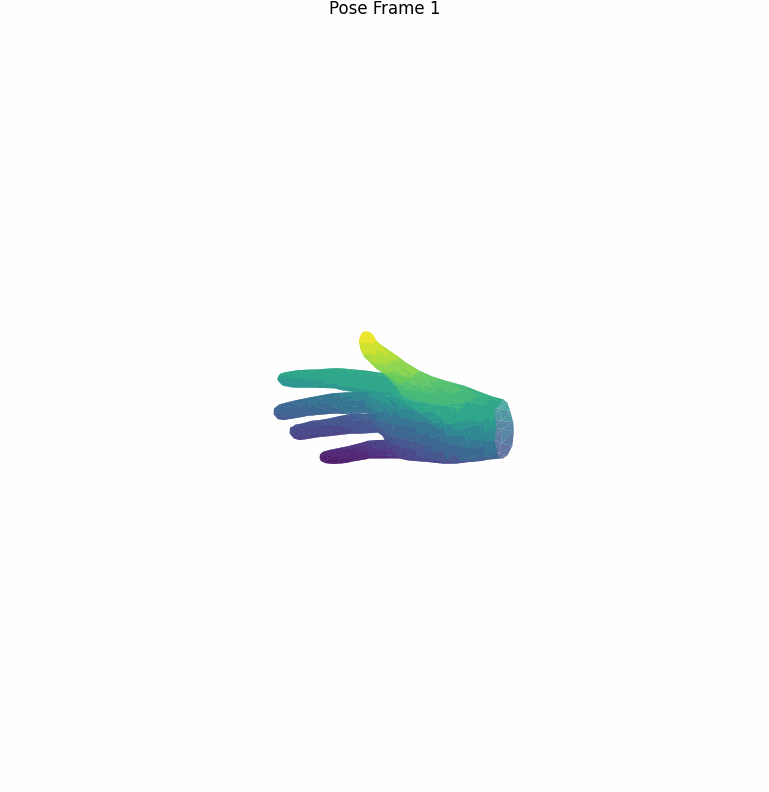

In [ ]:
from IPython.display import Image as DisplayImage
display(DisplayImage(filename=gif_path))